# 🫁 CXR DenseNet121 — Clasificación Multietiqueta (v6 · CPU · modelo independiente)
## TFM · Sistema de Apoyo a la Decisión Clínica Multimodal · Módulo de Imagen
### Universidad de Salamanca · Máster en Análisis Avanzado de Datos Multivariantes y Big Data

---

## 🎯 Qué es este notebook

Modelo **independiente** de clasificación de **radiografías de tórax** para las 6 etiquetas
`Atelectasis, Cardiomegaly, Edema, Lung Opacity, No Finding, Pleural Effusion`. Es un modelo
autónomo: entrena, se valida y se evalúa **por sí mismo**, sin ninguna dependencia de otras
modalidades ni de ninguna fusión posterior.

## 🔑 Decisiones de diseño

| # | Qué | Por qué |
|---|---|---|
| **A** | Preprocesado alineado con torchxrayvision: 1 canal, min-max por imagen → **[−1024, 1024]**, **224×224** | Es el dominio de entrada que el backbone espera (en v3/v4 se le daba z-score ImageNet a 160 → AUC ≈ 0.50) |
| **B** | Backbone **DenseNet121 (`densenet121-res224-all`, CheXNet)**, congelado + embeddings cacheados | ~8M params, nativo 224, entrenado en estas patologías; viable en CPU |
| **C** | **Negativos derivados por exclusividad** con *No Finding* | Hace entrenables Atelectasis, Lung Opacity y *No Finding* (ver abajo) |

## 🩺 Tratamiento de No Finding (negativos derivados por exclusividad)

- Si `No Finding == 1` → las 5 patologías = **0** (negativo derivado).
- Si alguna patología `== 1` → `No Finding = **0**`.

Solo rellena **NaN**; nunca pisa valores explícitos ni inciertos. Configurable con un flag.

## 🛡️ El masking de NaN y −1 se mantiene intacto

| Valor original | label / mask | ¿Entra en la loss? |
|---|---|---|
| `1` | 1 / 1 | Sí |
| `0` | 0 / 1 | Sí |
| `-1` (incierto) | según `uncertainty_policy` / 1 | Sí (igual que v3/v4) |
| `NaN` cubierto por exclusividad | 0 / 1 → negativo derivado | **Sí (nuevo)** |
| `NaN` no cubierto | 0 / 0 | **No — sigue enmascarado** |

## 🔬 Flujo (modelo independiente)

1. Embeddings del backbone congelado (cacheados, ~30–45 min la 1ª vez).
2. **Optuna (TPE)** para hiperparámetros (CV interno).
3. **K-fold CV** → estimación honesta de rendimiento (media ± desv.).
4. **Modelo final** entrenado en todo el train; val para early stopping, umbrales y calibración.
5. **Evaluación única en test** + calibración isotónica.

## 📊 Salidas (ricas)

- Tabla de métricas por etiqueta (AUC, AP, F1, sensibilidad, especificidad) + macro core/patologías.
- **Matrices de confusión** por etiqueta · **curvas ROC** · **curvas Precisión-Recall** · **curvas de calibración** · **curvas de entrenamiento**.
- `summary_v6.json`, `metrics_per_label_v6.csv`, checkpoint del modelo y figuras PNG.

## ⏱️ Coste (i5-1135G7, 4 núcleos, sin GPU → CPU)

≈ 1 hora la 1ª vez (embeddings cacheados); minutos al re-ejecutar.


In [1]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 1 · INSTALACIÓN DE DEPENDENCIAS                                       ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import subprocess, sys
# torch + torchvision (CPU) solo si faltan; este equipo no tiene GPU -> build CPU.
try:
    import torch  # noqa: F401
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "torch", "torchvision",
                    "--index-url", "https://download.pytorch.org/whl/cpu", "-q"], check=True)
for pkg in ["torchxrayvision", "optuna", "scikit-learn", "pandas", "numpy",
            "matplotlib", "seaborn", "tqdm"]:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"], check=True)
print("Dependencias instaladas.")


Dependencias instaladas.


In [2]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 2 · IMPORTS, SEMILLAS, HILOS DE CPU Y DISPOSITIVO                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
import os, gc, json, time, copy, random, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, TensorDataset, WeightedRandomSampler

import torchxrayvision as xrv

from sklearn.model_selection import KFold
from sklearn.metrics import (roc_auc_score, average_precision_score, f1_score,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.isotonic import IsotonicRegression

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
N_CORES = 4
torch.set_num_threads(N_CORES)
os.environ["OMP_NUM_THREADS"] = str(N_CORES); os.environ["MKL_NUM_THREADS"] = str(N_CORES)
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch {torch.__version__} · xrv {xrv.__version__} · Dispositivo {DEVICE} · Hilos {torch.get_num_threads()}")


c:\TFM\1.Opción - Symile Mimic\tfm_multimodal_clinico\venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.8.0+cpu · xrv 1.4.0 · Dispositivo cpu · Hilos 4


In [3]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 3 · RUTAS, ETIQUETAS Y CONSTANTES                                     ║
# ╚══════════════════════════════════════════════════════════════════════════╝
BASE = Path(r"C:\TFM\1.Opción - Symile Mimic\symile-mimic-a-multimodal-clinical-dataset-of-chest-x-rays-electrocardiograms-and-blood-labs-from-mimic-iv-1.0.0")
CSV_DIR = BASE / "data_csv" / "clean"
TRAIN_CSV, VAL_CSV, TEST_CSV = CSV_DIR/"train_clean.csv", CSV_DIR/"val_clean.csv", CSV_DIR/"test_clean.csv"
NPY = BASE / "data_npy"
CXR_TRAIN_NPY, CXR_VAL_NPY, CXR_TEST_NPY = NPY/"train"/"cxr_train.npy", NPY/"val"/"cxr_val.npy", NPY/"test"/"cxr_test.npy"
HADM_TRAIN_NPY, HADM_VAL_NPY, HADM_TEST_NPY = NPY/"train"/"hadm_id_train.npy", NPY/"val"/"hadm_id_val.npy", NPY/"test"/"hadm_id_test.npy"

OUTPUT_DIR = Path("outputs_cxr_densenet121_v6"); OUTPUT_DIR.mkdir(exist_ok=True)
EMB_DIR = OUTPUT_DIR / "embeddings"; EMB_DIR.mkdir(exist_ok=True)
FIG_DIR = OUTPUT_DIR / "figuras"; FIG_DIR.mkdir(exist_ok=True)

LABELS = ["Atelectasis", "Cardiomegaly", "Edema", "Lung Opacity", "No Finding", "Pleural Effusion"]
N_LABELS = len(LABELS); NO_FINDING = "No Finding"
PATHOLOGY_LABELS = [l for l in LABELS if l != NO_FINDING]
CORE_LABELS = ["Cardiomegaly", "Edema", "Pleural Effusion"]

IMG_SIZE = 224; XRV_RANGE = 1024.0; BACKBONE_WEIGHTS = "densenet121-res224-all"
DERIVE_NEGATIVES_FROM_EXCLUSIVITY = True

# Metadatos clínicos: edad, sexo, raza(5), tipo_ingreso(4), lugar_ingreso(4), horas(1), vista(2)
GENDER_MAP    = {0: 0, 1: 1, "0": 0, "1": 1, "M": 1, "F": 0}
RACE_MAP      = {"UNKNOWN": 0, "WHITE": 1, "BLACK": 2, "ASIAN": 3, "HISPANIC_LATINO": 4, "OTHER_KNOWN": 0}
ADMISSION_MAP = {"SCHEDULED": 0, "EMERGENCY": 1, "OBSERVATION": 2, "URGENT": 3}
ADM_LOC_MAP   = {"EMERGENCY_ROOM": 0, "REFERRAL": 1, "TRANSFER": 2, "INTRA_HOSPITAL": 3}
CXR_VIEW_MAP  = {"AP": 0, "PA": 1}
RACE_ONEHOT   = 5
META_DIM = 1 + 1 + RACE_ONEHOT + len(ADMISSION_MAP) + len(ADM_LOC_MAP) + 1 + len(CXR_VIEW_MAP)  # = 18

OPTUNA_TRIALS, K_FOLDS = 25, 5
TUNE_EPOCHS, TUNE_PATIENCE = 20, 5
FINAL_EPOCHS, FINAL_PATIENCE = 40, 8
HEAD_BATCH, EMB_BATCH = 128, 16

print(f"Backbone {BACKBONE_WEIGHTS} @ {IMG_SIZE} · META_DIM={META_DIM} · derive_neg={DERIVE_NEGATIVES_FROM_EXCLUSIVITY}")


Backbone densenet121-res224-all @ 224 · META_DIM=18 · derive_neg=True


In [4]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 4 · CARGA Y ALINEACIÓN CSV <-> NPY (join por hadm_id)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def load_split(csv_path, cxr_npy_path, hadm_npy_path, name):
    df = pd.read_csv(csv_path, sep=";")
    hadm = np.load(hadm_npy_path, allow_pickle=True)
    h2i = {int(h): i for i, h in enumerate(hadm)}
    df["_npy_idx"] = df["hadm_id"].map(lambda h: h2i.get(int(h), -1))
    n0 = len(df); df = df[df["_npy_idx"] >= 0].reset_index(drop=True)
    cxr = np.load(cxr_npy_path, mmap_mode="r")
    print(f"{name:5s}: CSV={n0:,} con imagen={len(df):,} (descartadas {n0-len(df)}) · CXR {cxr.shape}")
    return df, cxr

df_train, cxr_train = load_split(TRAIN_CSV, CXR_TRAIN_NPY, HADM_TRAIN_NPY, "train")
df_val,   cxr_val   = load_split(VAL_CSV,   CXR_VAL_NPY,   HADM_VAL_NPY,   "val")
df_test,  cxr_test  = load_split(TEST_CSV,  CXR_TEST_NPY,  HADM_TEST_NPY,  "test")


train: CSV=10,000 con imagen=10,000 (descartadas 0) · CXR (10000, 3, 320, 320)
val  : CSV=750 con imagen=750 (descartadas 0) · CXR (750, 3, 320, 320)
test : CSV=464 con imagen=464 (descartadas 0) · CXR (4640, 3, 320, 320)


In [5]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 5 · OBJETIVOS: MASKING + NEGATIVOS DERIVADOS                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def build_targets(df, uncertainty_policy="zeros", derive=DERIVE_NEGATIVES_FROM_EXCLUSIVITY, verbose=False):
    raw = df[LABELS].to_numpy(dtype=float); N = raw.shape[0]
    labels = np.zeros((N, N_LABELS), dtype=np.float32); mask = np.zeros((N, N_LABELS), dtype=np.float32)
    mask[~np.isnan(raw)] = 1.0
    labels[raw == 1] = 1.0
    unc = (raw == -1); labels[unc] = 1.0 if uncertainty_policy == "ones" else 0.0
    nf = LABELS.index(NO_FINDING); path_cols = [j for j in range(N_LABELS) if j != nf]
    n_dp = n_dn = n_c = 0
    if derive:
        nf_pos = (raw[:, nf] == 1)
        for j in path_cols:
            fill = nf_pos & np.isnan(raw[:, j]); labels[fill, j] = 0.0; mask[fill, j] = 1.0; n_dp += int(fill.sum())
        n_c = int((nf_pos[:, None] & (raw[:, path_cols] == 1)).sum())
        anyp = (raw[:, path_cols] == 1).any(axis=1)
        fnf = anyp & np.isnan(raw[:, nf]); labels[fnf, nf] = 0.0; mask[fnf, nf] = 1.0; n_dn = int(fnf.sum())
    if verbose:
        print(f"   Neg. derivados patologías={n_dp:,} · No Finding={n_dn:,} · contradicciones={n_c:,}")
    return labels, mask

print("== Balance efectivo 'train' ==")
_y, _m = build_targets(df_train, "zeros", verbose=True)
for j, lbl in enumerate(LABELS):
    sel = _m[:, j] == 1; pos = int((_y[sel, j] == 1).sum()); neg = int((_y[sel, j] == 0).sum())
    print(f"   {lbl:18s} pos={pos:5d} neg={neg:5d} enmascarados={int((_m[:,j]==0).sum()):5d}")


== Balance efectivo 'train' ==
   Neg. derivados patologías=6,091 · No Finding=7,691 · contradicciones=0
   Atelectasis        pos= 2867 neg= 2052 enmascarados= 5081
   Cardiomegaly       pos= 3346 neg= 2495 enmascarados= 4159
   Edema              pos= 2067 neg= 3735 enmascarados= 4198
   Lung Opacity       pos= 3108 neg= 1733 enmascarados= 5159
   No Finding         pos= 1368 neg= 7691 enmascarados=  941
   Pleural Effusion   pos= 3618 neg= 3194 enmascarados= 3188


In [6]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 6 · METADATOS CLÍNICOS (18 dims)                                      ║
# ╚══════════════════════════════════════════════════════════════════════════╝
AGE_MIN, AGE_MAX = float(df_train["age"].min()), float(df_train["age"].max())
HRS_MIN, HRS_MAX = float(df_train["hours_adm_to_cxr"].min()), float(df_train["hours_adm_to_cxr"].max())

def build_metadata(df):
    # edad, sexo, raza(5), tipo de ingreso(4), lugar de ingreso(4), horas(1), vista(2).
    # admission_location y hours_adm_to_cxr se incluyen como contexto clinico (proxy de gravedad).
    N = len(df); M = np.zeros((N, META_DIM), dtype=np.float32)
    for i, (_, row) in enumerate(df.iterrows()):
        off = 0
        M[i, off] = (float(row.get("age", AGE_MIN)) - AGE_MIN) / (AGE_MAX - AGE_MIN + 1e-8); off += 1
        M[i, off] = float(GENDER_MAP.get(row.get("gender", 0), 0)); off += 1
        M[i, off + RACE_MAP.get(str(row.get("race", "UNKNOWN")).upper(), 0)] = 1.0; off += RACE_ONEHOT
        M[i, off + ADMISSION_MAP.get(str(row.get("admission_type", "EMERGENCY")).upper(), 1)] = 1.0; off += len(ADMISSION_MAP)
        M[i, off + ADM_LOC_MAP.get(str(row.get("admission_location", "EMERGENCY_ROOM")).upper(), 0)] = 1.0; off += len(ADM_LOC_MAP)
        M[i, off] = (float(row.get("hours_adm_to_cxr", HRS_MIN)) - HRS_MIN) / (HRS_MAX - HRS_MIN + 1e-8); off += 1
        M[i, off + CXR_VIEW_MAP.get(str(row.get("cxr_view", "AP")).upper(), 0)] = 1.0; off += len(CXR_VIEW_MAP)
    return M

meta_train, meta_val, meta_test = build_metadata(df_train), build_metadata(df_val), build_metadata(df_test)
print(f"Metadatos: train={meta_train.shape} val={meta_val.shape} test={meta_test.shape}")


Metadatos: train=(10000, 18) val=(750, 18) test=(464, 18)


In [7]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 7 · PREPROCESADO DE IMAGEN (alineado con torchxrayvision)            ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class CXRImageDataset(Dataset):
    def __init__(self, df, cxr_npy): self.idx = df["_npy_idx"].to_numpy(); self.cxr = cxr_npy
    def __len__(self): return len(self.idx)
    def __getitem__(self, i):
        arr = np.asarray(self.cxr[int(self.idx[i])], dtype=np.float32)
        g = arr[0] if arr.ndim == 3 else arr
        g = (g - g.min()) / (g.max() - g.min() + 1e-8)
        g = (2.0 * g - 1.0) * XRV_RANGE
        t = torch.from_numpy(g)[None, None]
        return F.interpolate(t, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)[0]

_s = CXRImageDataset(df_train, cxr_train)[0]
print(f"Muestra: {tuple(_s.shape)} min={_s.min():.0f} max={_s.max():.0f} (esperado ~[-1024,1024])")


Muestra: (1, 224, 224) min=-1023 max=1023 (esperado ~[-1024,1024])


In [8]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 8 · BACKBONE DenseNet121 + EXTRACCIÓN DE EMBEDDINGS                   ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def load_backbone():
    m = xrv.models.DenseNet(weights=BACKBONE_WEIGHTS); m.eval()
    for p in m.parameters(): p.requires_grad = False
    return m.to(DEVICE)

@torch.no_grad()
def extract_embeddings(model, df, cxr_npy, desc):
    loader = DataLoader(CXRImageDataset(df, cxr_npy), batch_size=EMB_BATCH, shuffle=False, num_workers=0)
    out = []
    for x in tqdm(loader, desc=desc, leave=False):
        f = model.features(x.to(DEVICE)); f = F.relu(f, inplace=True)
        out.append(F.adaptive_avg_pool2d(f, (1, 1)).reshape(f.shape[0], -1).cpu().numpy())
    return np.concatenate(out, axis=0).astype(np.float32)
print("Backbone listo (se descargará la 1ª vez).")


Backbone listo (se descargará la 1ª vez).


In [9]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 9 · CALCULAR (O CARGAR) EMBEDDINGS — único paso lento                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
PT = {s: EMB_DIR / f"emb_{s}.npy" for s in ["train", "val", "test"]}
if all(p.exists() for p in PT.values()):
    emb_train, emb_val, emb_test = (np.load(PT["train"]), np.load(PT["val"]), np.load(PT["test"]))
    print("Embeddings cargados de caché.")
else:
    t0 = time.time(); bb = load_backbone()
    emb_train = extract_embeddings(bb, df_train, cxr_train, "train"); np.save(PT["train"], emb_train)
    emb_val   = extract_embeddings(bb, df_val,   cxr_val,   "val");   np.save(PT["val"],   emb_val)
    emb_test  = extract_embeddings(bb, df_test,  cxr_test,  "test");  np.save(PT["test"],  emb_test)
    del bb; gc.collect(); print(f"Embeddings calculados en {(time.time()-t0)/60:.1f} min.")
EMB_DIM = emb_train.shape[1]
print(f"emb_train={emb_train.shape} emb_val={emb_val.shape} emb_test={emb_test.shape} EMB_DIM={EMB_DIM}")


Embeddings calculados en 78.6 min.
emb_train=(10000, 1024) emb_val=(750, 1024) emb_test=(464, 1024) EMB_DIM=1024


In [10]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 10 · CABEZA + PÉRDIDA ENMASCARADA + MÉTRICAS                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
class LabelCorrelation(nn.Module):
    def __init__(self, n=N_LABELS):
        super().__init__(); self.lin = nn.Linear(n, n, bias=False)
        nn.init.eye_(self.lin.weight); self.lin.weight.data *= 0.1; self.norm = nn.LayerNorm(n)
    def forward(self, x): return self.norm(x + self.lin(x))

class CXRHead(nn.Module):
    def __init__(self, emb_dim=EMB_DIM, dropout=0.3, use_corr=True, use_meta=True):
        super().__init__(); self.use_meta = use_meta
        self.img = nn.Sequential(nn.Linear(emb_dim, 512), nn.BatchNorm1d(512), nn.ReLU(inplace=True))
        if use_meta:
            self.meta = nn.Sequential(nn.Linear(META_DIM, 64), nn.BatchNorm1d(64), nn.ReLU(inplace=True)); fused = 512 + 64
        else: self.meta = None; fused = 512
        self.head = nn.Sequential(nn.Dropout(dropout), nn.Linear(fused, 256), nn.BatchNorm1d(256),
                                  nn.ReLU(inplace=True), nn.Dropout(dropout*0.5), nn.Linear(256, N_LABELS))
        self.corr = LabelCorrelation() if use_corr else None
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                if m.bias is not None: nn.init.zeros_(m.bias)
    def forward(self, emb, meta=None):
        z = self.img(emb)
        if self.use_meta and meta is not None: z = torch.cat([z, self.meta(meta)], dim=1)
        logits = self.head(z)
        return self.corr(logits) if self.corr is not None else logits

class MaskedLoss(nn.Module):
    def __init__(self, pos_weight, loss_type="bce", focal_gamma=2.0):
        super().__init__(); self.register_buffer("pos_weight", pos_weight)
        self.loss_type = loss_type; self.gamma = focal_gamma
    def forward(self, logits, labels, mask):
        pw = self.pos_weight.to(logits.device)
        if self.loss_type == "focal":
            bce = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw, reduction="none")
            p = torch.sigmoid(logits); pt = labels*p + (1-labels)*(1-p); loss = ((1-pt)**self.gamma)*bce
        else:
            loss = F.binary_cross_entropy_with_logits(logits, labels, pos_weight=pw, reduction="none")
        loss = loss * mask
        return loss.sum() / mask.sum().clamp(min=1e-8)

def dynamic_pos_weights(y, m, clip=10.0):
    w = np.ones(N_LABELS, dtype=np.float32)
    for j in range(N_LABELS):
        sel = m[:, j] == 1; pos = (y[sel, j] == 1).sum(); neg = (y[sel, j] == 0).sum()
        w[j] = np.clip(neg / max(pos, 1), 1.0/clip, clip)
    return torch.tensor(w, dtype=torch.float32)

def sample_weights_by_rarity(y, m):
    combo = [tuple(int(v) for v in (y[i]*m[i]).astype(int)) for i in range(len(y))]
    c = Counter(combo); return torch.tensor([1.0/c[k] for k in combo], dtype=torch.double)

def multilabel_metrics(probs, labels, mask, thresholds=None):
    if thresholds is None: thresholds = {l: 0.5 for l in LABELS}
    res = {}
    for j, lbl in enumerate(LABELS):
        sel = mask[:, j] == 1; yt = labels[sel, j]; yp = probs[sel, j]
        npos = int(yt.sum()); nneg = int((1-yt).sum()); thr = thresholds.get(lbl, 0.5)
        pred = (yp >= thr).astype(float)
        if npos >= 2 and nneg >= 2:
            auc = roc_auc_score(yt, yp); ap = average_precision_score(yt, yp)
        else: auc = ap = float("nan")
        tp = int(((pred==1)&(yt==1)).sum()); tn = int(((pred==0)&(yt==0)).sum())
        fp = int(((pred==1)&(yt==0)).sum()); fn = int(((pred==0)&(yt==1)).sum())
        sens = tp/max(tp+fn,1); spec = tn/max(tn+fp,1)
        res[lbl] = {"AUC": auc, "AP": ap, "F1": f1_score(yt, pred, zero_division=0),
                    "sens": sens, "spec": spec, "n_pos": npos, "n_neg": nneg, "thr": thr,
                    "TP": tp, "TN": tn, "FP": fp, "FN": fn}
    def macro(g):
        v = [res[l]["AUC"] for l in g if not np.isnan(res[l]["AUC"])]; return float(np.mean(v)) if v else float("nan")
    res["macro_AUC_core"] = macro(CORE_LABELS); res["macro_AUC_path"] = macro(PATHOLOGY_LABELS)
    return res

def best_thresholds_by_f1(probs, labels, mask, grid=None):
    if grid is None: grid = np.linspace(0.05, 0.95, 37)
    thr = {}
    for j, lbl in enumerate(LABELS):
        sel = mask[:, j] == 1; yt = labels[sel, j]; yp = probs[sel, j]
        if yt.sum() < 2: thr[lbl] = 0.5; continue
        bf, bt = -1, 0.5
        for t in grid:
            f = f1_score(yt, (yp >= t).astype(float), zero_division=0)
            if f > bf: bf, bt = f, t
        thr[lbl] = float(bt)
    return thr
print("Cabeza, pérdida y métricas definidas.")


Cabeza, pérdida y métricas definidas.


In [11]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 11 · ENTRENAMIENTO / PREDICCIÓN DE LA CABEZA                          ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def make_loader(emb, meta, y, m, cfg, train=True):
    ds = TensorDataset(torch.tensor(emb), torch.tensor(meta), torch.tensor(y), torch.tensor(m))
    if train and cfg.get("use_sampler", False):
        sw = sample_weights_by_rarity(y, m)
        return DataLoader(ds, batch_size=HEAD_BATCH, sampler=WeightedRandomSampler(sw, len(sw), True), drop_last=True)
    return DataLoader(ds, batch_size=HEAD_BATCH, shuffle=train, drop_last=train)

@torch.no_grad()
def predict_head(head, emb, meta):
    head.eval(); out = []
    for i in range(0, len(emb), 512):
        out.append(torch.sigmoid(head(torch.tensor(emb[i:i+512]).to(DEVICE),
                                       torch.tensor(meta[i:i+512]).to(DEVICE))).cpu().numpy())
    return np.concatenate(out, axis=0)

def train_head(emb_tr, meta_tr, y_tr, m_tr, emb_va, meta_va, y_va, m_va, cfg, n_epochs, patience):
    criterion = MaskedLoss(dynamic_pos_weights(y_tr, m_tr), cfg.get("loss_type","bce")).to(DEVICE)
    head = CXRHead(EMB_DIM, cfg["dropout"], cfg["use_corr"], cfg["use_meta"]).to(DEVICE)
    opt = torch.optim.AdamW(head.parameters(), lr=cfg["lr"], weight_decay=cfg["weight_decay"])
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=n_epochs, eta_min=1e-7)
    loader = make_loader(emb_tr, meta_tr, y_tr, m_tr, cfg, train=True)
    best_auc, best_state, waited = -1.0, None, 0
    history = {"train_loss": [], "val_auc": []}
    for ep in range(n_epochs):
        head.train(); tl, nb = 0.0, 0
        for eb, mb, yb, msb in loader:
            eb, mb, yb, msb = eb.to(DEVICE), mb.to(DEVICE), yb.to(DEVICE), msb.to(DEVICE)
            opt.zero_grad(); loss = criterion(head(eb, mb), yb, msb); loss.backward()
            torch.nn.utils.clip_grad_norm_(head.parameters(), 1.0); opt.step(); tl += loss.item(); nb += 1
        sched.step()
        score = multilabel_metrics(predict_head(head, emb_va, meta_va), y_va, m_va)["macro_AUC_path"]
        history["train_loss"].append(tl/max(nb,1)); history["val_auc"].append(score)
        if not np.isnan(score) and score > best_auc + 1e-4:
            best_auc, best_state, waited = score, copy.deepcopy(head.state_dict()), 0
        else:
            waited += 1
            if waited >= patience: break
    if best_state is not None: head.load_state_dict(best_state)
    return head, best_auc, history
print("Entrenamiento/predicción listos.")


Entrenamiento/predicción listos.


In [12]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 12 · OPTUNA — búsqueda de hiperparámetros (CV interno 3-fold)         ║
# ╚══════════════════════════════════════════════════════════════════════════╝
def objective(trial):
    cfg = {"lr": trial.suggest_float("lr", 1e-4, 5e-3, log=True),
           "weight_decay": trial.suggest_float("weight_decay", 1e-5, 1e-3, log=True),
           "dropout": trial.suggest_float("dropout", 0.1, 0.5),
           "use_corr": trial.suggest_categorical("use_corr", [True, False]),
           "use_meta": trial.suggest_categorical("use_meta", [True, False]),
           "use_sampler": trial.suggest_categorical("use_sampler", [True, False]),
           "loss_type": trial.suggest_categorical("loss_type", ["bce", "focal"]),
           "policy": trial.suggest_categorical("policy", ["zeros", "ones"])}
    y_all, m_all = build_targets(df_train, cfg["policy"])
    kf = KFold(3, shuffle=True, random_state=SEED); sc = []
    for tr, va in kf.split(np.arange(len(df_train))):
        h, _, _ = train_head(emb_train[tr], meta_train[tr], y_all[tr], m_all[tr],
                             emb_train[va], meta_train[va], y_all[va], m_all[va], cfg, TUNE_EPOCHS, TUNE_PATIENCE)
        sc.append(multilabel_metrics(predict_head(h, emb_train[va], meta_train[va]), y_all[va], m_all[va])["macro_AUC_path"])
        del h; gc.collect()
    return float(np.nanmean(sc))

t0 = time.time()
study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=OPTUNA_TRIALS, show_progress_bar=True)
BEST = study.best_params
print(f"\nOptuna {(time.time()-t0)/60:.1f} min · mejor macroAUC_path={study.best_value:.4f}")
for k, v in BEST.items(): print(f"   {k:14s} = {v}")


Best trial: 17. Best value: 0.823851: 100%|██████████| 25/25 [35:23<00:00, 84.94s/it] 


Optuna 35.4 min · mejor macroAUC_path=0.8239
   lr             = 0.0012509616549487318
   weight_decay   = 5.056290750946613e-05
   dropout        = 0.49002235986243886
   use_corr       = False
   use_meta       = True
   use_sampler    = False
   loss_type      = bce
   policy         = ones


In [13]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 13 · K-FOLD CV — estimación honesta de rendimiento (media ± desv.)    ║
# ╚══════════════════════════════════════════════════════════════════════════╝
cfg = dict(BEST)
y_train, m_train = build_targets(df_train, cfg["policy"])
y_val,   m_val   = build_targets(df_val,   cfg["policy"])
y_test,  m_test  = build_targets(df_test,  cfg["policy"])

kf = KFold(K_FOLDS, shuffle=True, random_state=SEED)
fold_rows = []
for k, (tr, va) in enumerate(kf.split(np.arange(len(df_train)))):
    h, _, _ = train_head(emb_train[tr], meta_train[tr], y_train[tr], m_train[tr],
                         emb_train[va], meta_train[va], y_train[va], m_train[va], cfg, FINAL_EPOCHS, FINAL_PATIENCE)
    mm = multilabel_metrics(predict_head(h, emb_train[va], meta_train[va]), y_train[va], m_train[va])
    fold_rows.append(mm)
    print(f"Fold {k+1}/{K_FOLDS}: macroAUC_path={mm['macro_AUC_path']:.4f} core={mm['macro_AUC_core']:.4f}")
    del h; gc.collect()

cv_core = [f["macro_AUC_core"] for f in fold_rows]; cv_path = [f["macro_AUC_path"] for f in fold_rows]
print(f"\nCV {K_FOLDS}-fold · core={np.nanmean(cv_core):.4f}±{np.nanstd(cv_core):.4f} · "
      f"path={np.nanmean(cv_path):.4f}±{np.nanstd(cv_path):.4f}")
print("AUC por etiqueta (media±desv en CV):")
for lbl in LABELS:
    a = [f[lbl]["AUC"] for f in fold_rows]
    print(f"   {lbl:18s} {np.nanmean(a):.4f} ± {np.nanstd(a):.4f}")


Fold 1/5: macroAUC_path=0.8299 core=0.8360
Fold 2/5: macroAUC_path=0.8203 core=0.8355
Fold 3/5: macroAUC_path=0.8253 core=0.8385
Fold 4/5: macroAUC_path=0.8292 core=0.8447
Fold 5/5: macroAUC_path=0.8242 core=0.8355

CV 5-fold · core=0.8380±0.0035 · path=0.8258±0.0035
AUC por etiqueta (media±desv en CV):
   Atelectasis        0.8083 ± 0.0087
   Cardiomegaly       0.7994 ± 0.0117
   Edema              0.8439 ± 0.0088
   Lung Opacity       0.8065 ± 0.0086
   No Finding         0.7980 ± 0.0133
   Pleural Effusion   0.8708 ± 0.0087


In [14]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 14 · MODELO FINAL (todo el train) + CALIBRACIÓN (val)                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
final_head, _, history = train_head(emb_train, meta_train, y_train, m_train,
                                    emb_val, meta_val, y_val, m_val, cfg, FINAL_EPOCHS, FINAL_PATIENCE)
val_pred = predict_head(final_head, emb_val, meta_val)

# Calibración isotónica por etiqueta (ajustada en val)
calibrators = {}
for j, lbl in enumerate(LABELS):
    sel = m_val[:, j] == 1; yt = y_val[sel, j]; yp = val_pred[sel, j]
    if len(np.unique(yt)) < 2: calibrators[lbl] = None; continue
    iso = IsotonicRegression(out_of_bounds="clip"); iso.fit(yp, yt); calibrators[lbl] = iso
def apply_cal(p):
    o = p.copy()
    for j, lbl in enumerate(LABELS):
        if calibrators[lbl] is not None: o[:, j] = calibrators[lbl].predict(p[:, j])
    return o

thr_val = best_thresholds_by_f1(apply_cal(val_pred), y_val, m_val)
torch.save({"state_dict": final_head.state_dict(), "config": cfg, "thresholds": thr_val},
           OUTPUT_DIR / "modelo_final_v6.pt")
print("Modelo final entrenado, calibrado y guardado (modelo_final_v6.pt).")


Modelo final entrenado, calibrado y guardado (modelo_final_v6.pt).


In [15]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 15 · EVALUACIÓN EN TEST + TABLA DE MÉTRICAS                           ║
# ╚══════════════════════════════════════════════════════════════════════════╝
test_pred = apply_cal(predict_head(final_head, emb_test, meta_test))
M = multilabel_metrics(test_pred, y_test, m_test, thresholds=thr_val)

rows = []
print(f"{'Etiqueta':18s} {'AUC':>7} {'AP':>7} {'F1':>7} {'Sens':>6} {'Spec':>6} {'N+':>5} {'N-':>5}")
print("-" * 74)
for lbl in LABELS:
    m = M[lbl]; auc = f"{m['AUC']:.4f}" if not np.isnan(m['AUC']) else "  N/A"
    print(f"{lbl:18s} {auc:>7} {m['AP']:7.4f} {m['F1']:7.4f} {m['sens']:6.3f} {m['spec']:6.3f} {m['n_pos']:5d} {m['n_neg']:5d}")
    rows.append({"label": lbl, **{k: m[k] for k in ["AUC","AP","F1","sens","spec","n_pos","n_neg","TP","TN","FP","FN","thr"]}})
print("-" * 74)
print(f"{'MACRO core (3)':18s} {M['macro_AUC_core']:.4f}   ·   MACRO patol. (5) {M['macro_AUC_path']:.4f}")

pd.DataFrame(rows).to_csv(OUTPUT_DIR / "metrics_per_label_v6.csv", index=False)
summary = {"version": "CXR v6 DenseNet121 (independiente)", "backbone": BACKBONE_WEIGHTS, "best_config": BEST,
           "cv_macro_core": [float(np.nanmean(cv_core)), float(np.nanstd(cv_core))],
           "cv_macro_path": [float(np.nanmean(cv_path)), float(np.nanstd(cv_path))],
           "test_macro_core": M["macro_AUC_core"], "test_macro_path": M["macro_AUC_path"],
           "test_per_label": {l: M[l] for l in LABELS}}
with open(OUTPUT_DIR / "summary_v6.json", "w", encoding="utf-8") as f:
    json.dump(summary, f, indent=2, default=str, ensure_ascii=False)
print("Guardados metrics_per_label_v6.csv y summary_v6.json")


Etiqueta               AUC      AP      F1   Sens   Spec    N+    N-
--------------------------------------------------------------------------
Atelectasis         0.7844  0.8572  0.8448  0.902  0.479   163    73
Cardiomegaly        0.7777  0.8112  0.7889  0.866  0.514   164   111
Edema               0.8291  0.7947  0.7203  0.777  0.678   121   143
Lung Opacity        0.7931  0.8387  0.8123  0.832  0.613   143    80
No Finding          0.7597  0.3910  0.4872  0.551  0.860    69   349
Pleural Effusion    0.8542  0.8521  0.8084  0.851  0.687   181   147
--------------------------------------------------------------------------
MACRO core (3)     0.8204   ·   MACRO patol. (5) 0.8077
Guardados metrics_per_label_v6.csv y summary_v6.json


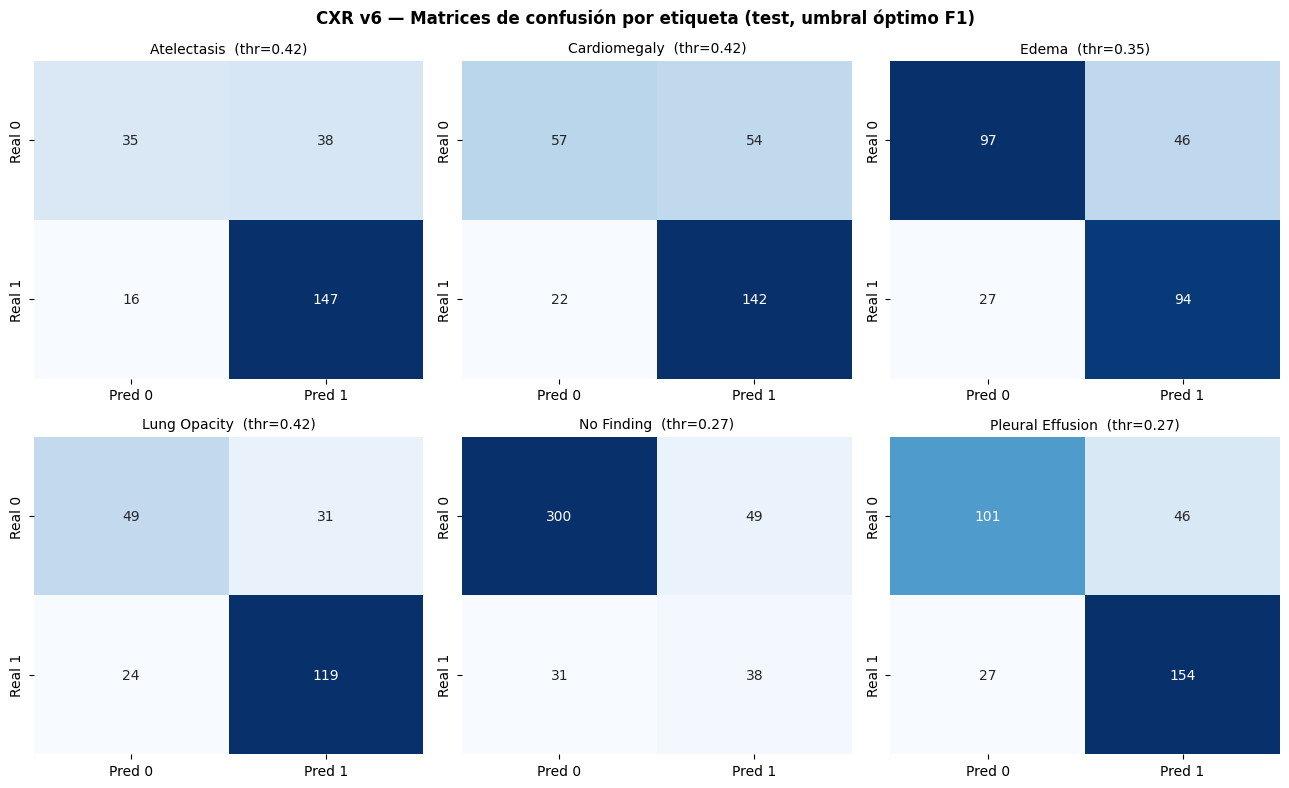

Matrices de confusión guardadas.


In [16]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 16 · MATRICES DE CONFUSIÓN POR ETIQUETA                              ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 3, figsize=(13, 8))
fig.suptitle("CXR v6 — Matrices de confusión por etiqueta (test, umbral óptimo F1)", fontweight="bold")
for j, lbl in enumerate(LABELS):
    ax = axes[j//3, j%3]; sel = m_test[:, j] == 1
    yt = y_test[sel, j]; yp = (test_pred[sel, j] >= thr_val.get(lbl, 0.5)).astype(int)
    if len(yt) == 0: ax.axis("off"); continue
    cm = confusion_matrix(yt, yp, labels=[0, 1])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=ax,
                xticklabels=["Pred 0", "Pred 1"], yticklabels=["Real 0", "Real 1"])
    ax.set_title(f"{lbl}  (thr={thr_val.get(lbl,0.5):.2f})", fontsize=10)
plt.tight_layout(); plt.savefig(FIG_DIR / "confusion_matrices_v6.png", dpi=150, bbox_inches="tight"); plt.show()
print("Matrices de confusión guardadas.")


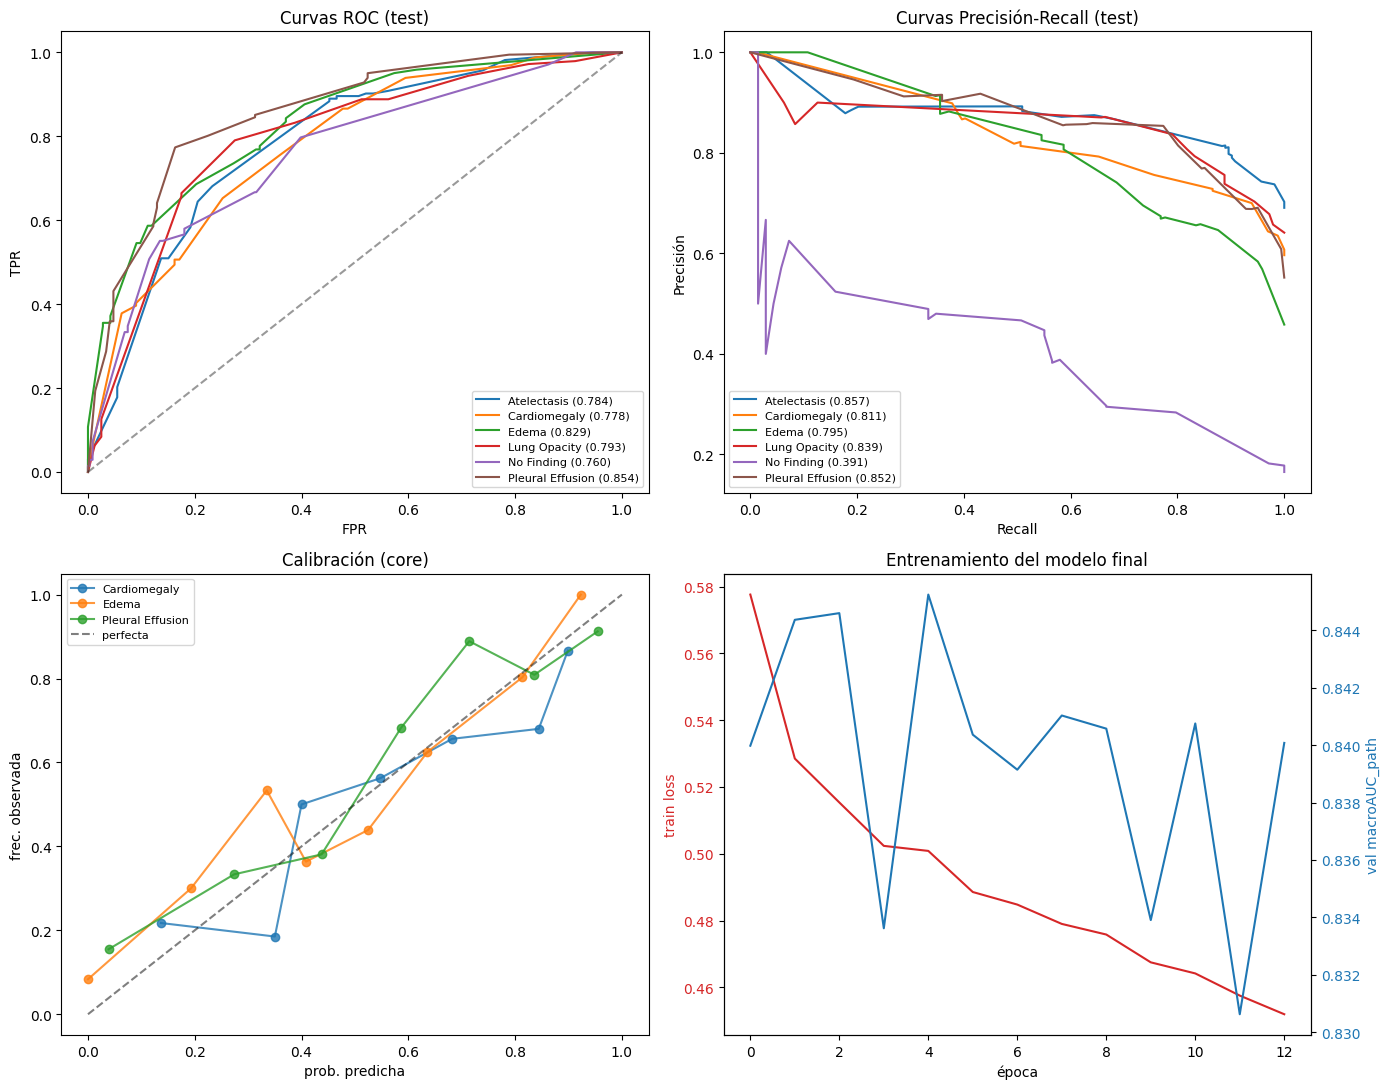

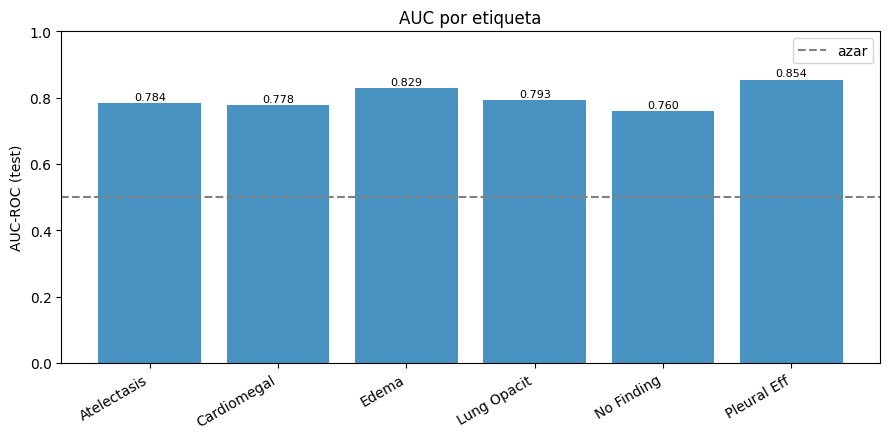

Curvas y barras guardadas en outputs_cxr_densenet121_v6\figuras


In [17]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 17 · CURVAS ROC, PRECISIÓN-RECALL, CALIBRACIÓN Y ENTRENAMIENTO        ║
# ╚══════════════════════════════════════════════════════════════════════════╝
fig, axes = plt.subplots(2, 2, figsize=(14, 11))

# (a) ROC
ax = axes[0, 0]
for j, lbl in enumerate(LABELS):
    sel = m_test[:, j] == 1; yt = y_test[sel, j]; yp = test_pred[sel, j]
    if len(np.unique(yt)) < 2: continue
    fpr, tpr, _ = roc_curve(yt, yp); ax.plot(fpr, tpr, label=f"{lbl} ({M[lbl]['AUC']:.3f})")
ax.plot([0,1],[0,1],"k--",alpha=0.4); ax.set_title("Curvas ROC (test)")
ax.set_xlabel("FPR"); ax.set_ylabel("TPR"); ax.legend(fontsize=8)

# (b) Precisión-Recall
ax = axes[0, 1]
for j, lbl in enumerate(LABELS):
    sel = m_test[:, j] == 1; yt = y_test[sel, j]; yp = test_pred[sel, j]
    if len(np.unique(yt)) < 2: continue
    pr, rc, _ = precision_recall_curve(yt, yp); ax.plot(rc, pr, label=f"{lbl} ({M[lbl]['AP']:.3f})")
ax.set_title("Curvas Precisión-Recall (test)"); ax.set_xlabel("Recall"); ax.set_ylabel("Precisión"); ax.legend(fontsize=8)

# (c) Calibración (core)
ax = axes[1, 0]
for lbl in CORE_LABELS:
    j = LABELS.index(lbl); sel = m_test[:, j] == 1; yt = y_test[sel, j]; yp = test_pred[sel, j]
    bins = np.linspace(0, 1, 9); idx = np.digitize(yp, bins) - 1; xs, ys = [], []
    for b in range(len(bins)-1):
        mb = idx == b
        if mb.sum() > 5: xs.append(yp[mb].mean()); ys.append(yt[mb].mean())
    ax.plot(xs, ys, "o-", label=lbl, alpha=0.8)
ax.plot([0,1],[0,1],"k--",alpha=0.5,label="perfecta"); ax.set_title("Calibración (core)")
ax.set_xlabel("prob. predicha"); ax.set_ylabel("frec. observada"); ax.legend(fontsize=8)

# (d) Entrenamiento del modelo final
ax = axes[1, 1]
ax.plot(history["train_loss"], label="train loss", color="tab:red")
ax.set_xlabel("época"); ax.set_ylabel("train loss", color="tab:red"); ax.tick_params(axis="y", labelcolor="tab:red")
ax2 = ax.twinx(); ax2.plot(history["val_auc"], label="val macroAUC_path", color="tab:blue")
ax2.set_ylabel("val macroAUC_path", color="tab:blue"); ax2.tick_params(axis="y", labelcolor="tab:blue")
ax.set_title("Entrenamiento del modelo final")

plt.tight_layout(); plt.savefig(FIG_DIR / "curvas_v6.png", dpi=150, bbox_inches="tight"); plt.show()

# AUC por etiqueta (barras)
fig2, ax = plt.subplots(figsize=(9, 4.5))
aucs = [M[l]["AUC"] for l in LABELS]
colors = ["#c0392b" if (np.isnan(a) or a < 0.55) else "#2980b9" for a in aucs]
ax.bar(range(N_LABELS), [0 if np.isnan(a) else a for a in aucs], color=colors, alpha=0.85)
ax.axhline(0.5, color="gray", ls="--", label="azar")
ax.set_xticks(range(N_LABELS)); ax.set_xticklabels([l[:11] for l in LABELS], rotation=30, ha="right")
ax.set_ylim(0, 1); ax.set_ylabel("AUC-ROC (test)"); ax.set_title("AUC por etiqueta"); ax.legend()
for i, a in enumerate(aucs):
    if not np.isnan(a): ax.text(i, a+0.01, f"{a:.3f}", ha="center", fontsize=8)
plt.tight_layout(); plt.savefig(FIG_DIR / "auc_por_etiqueta_v6.png", dpi=150, bbox_inches="tight"); plt.show()
print("Curvas y barras guardadas en", FIG_DIR)


In [18]:
# ╔══════════════════════════════════════════════════════════════════════════╗
# ║ CELDA 18 · ANÁLISIS DE EQUIDAD POR SUBGRUPO                                 ║
# ╚══════════════════════════════════════════════════════════════════════════╝
dft = df_test.reset_index(drop=True)
for col, label in [("gender","GÉNERO"), ("cxr_view","VISTA"), ("race","RAZA"), ("admission_type","INGRESO")]:
    if col not in dft.columns: continue
    print(f"\n-- AUC macro (patologías) por {label} --")
    for v in sorted(dft[col].dropna().unique(), key=str):
        idx = dft.index[dft[col] == v].to_numpy()
        if len(idx) < 15: print(f"   {str(v):22s} n={len(idx):4d} (insuficiente)"); continue
        mm = multilabel_metrics(test_pred[idx], y_test[idx], m_test[idx])
        print(f"   {str(v):22s} n={len(idx):4d}  macroAUC_path={mm['macro_AUC_path']:.4f}")
print("\nAnálisis de equidad completado.")



-- AUC macro (patologías) por GÉNERO --
   0                      n= 184  macroAUC_path=0.8342
   1                      n= 280  macroAUC_path=0.7904

-- AUC macro (patologías) por VISTA --
   AP                     n= 388  macroAUC_path=0.7806
   PA                     n=  76  macroAUC_path=0.8573

-- AUC macro (patologías) por RAZA --
   ASIAN                  n=  15  macroAUC_path=0.9023
   BLACK                  n=  58  macroAUC_path=0.7393
   HISPANIC_LATINO        n=  21  macroAUC_path=0.7320
   OTHER_KNOWN            n=   3 (insuficiente)
   UNKNOWN                n=  52  macroAUC_path=0.8781
   WHITE                  n= 315  macroAUC_path=0.8049

-- AUC macro (patologías) por INGRESO --
   EMERGENCY              n= 322  macroAUC_path=0.8042
   OBSERVATION            n=  66  macroAUC_path=0.8331
   SCHEDULED              n=  34  macroAUC_path=0.7165
   URGENT                 n=  42  macroAUC_path=0.8074

Análisis de equidad completado.


---
## ✅ Resumen — CXR v6 (modelo independiente)

- **Preprocesado correcto** + **DenseNet121 (CheXNet)** congelado con embeddings cacheados.
- **Negativos derivados por exclusividad** (No Finding) con **masking de NaN/−1 intacto**.
- `pos_weight` dinámico + BCE/focal + sampler por rareza · **Optuna** + **K-fold CV** + **modelo final** + **calibración isotónica**.
- Metadatos clínicos de 18 dims (incluye `admission_location` y `hours_adm_to_cxr`).

**Salidas:** `summary_v6.json`, `metrics_per_label_v6.csv`, `modelo_final_v6.pt`, y figuras en `figuras/`
(matrices de confusión, ROC, PR, calibración, curvas de entrenamiento, AUC por etiqueta).

**Nota:** es un modelo **autónomo**; no exporta predicciones por muestra ni depende de ninguna fusión.

## 🔧 Palancas
`DERIVE_NEGATIVES_FROM_EXCLUSIVITY`, `OPTUNA_TRIALS`, `K_FOLDS`, `FINAL_EPOCHS`, `BACKBONE_WEIGHTS`.
